In [26]:
import pandas as pd
import numpy as np
from scipy.spatial import Voronoi
from matplotlib import pyplot as plt

### 1. Generation of the particles coordinates on a square grid

In [69]:
# initialising parameters of the bidisperse mixture

# number of particles
nb_big_side = 10
nb_small_side = nb_big_side - 1
nb_big = nb_big_side**2
nb_small = nb_small_side**2

coord = np.zeros([nb_big+nb_small, 4])

# Physical size dimensions
dist_param = 1. # distance parameter to link with physical forces constants

side_size = 1. * dist_param
density_big = 1./(side_size**2)
density_small = 1./(side_size**2)
side_sample = nb_big_side * side_size
surface_sample = side_sample**2

# noise in positions of particles generation
noise_param = 0.05



In [70]:
# Generating coordinates array
idx = 0
np.random.seed(0)

def noise_gen(noise_param = noise_param): # generating quasi normal random noise with max abs noise set to side_size/10.
    noise = 0.
    if noise_param * side_size * np.random.randn() >= 0. :
        noise = np.min([noise_param * side_size * np.random.randn(), side_size/10.])
    else:
        noise = np.max(([noise_param * side_size * np.random.randn(), -side_size/10.]))

    return noise

# for big particles
for j in range(nb_big_side): # columns generation
    pos_y = side_size/2. + j * side_size + noise_gen()
    

    for i in range(nb_big_side): # rows generation
        pos_x = side_size/2. + i * side_size + noise_gen()

        coord[idx, 0] = idx
        coord[idx, 1] = pos_x
        coord[idx, 2] = pos_y
        coord[idx, 3] = 1

        idx += 1

# for small particles
for j in range(nb_small_side): # columns generation
    pos_y = side_size + j * side_size + noise_gen()
    

    for i in range(nb_small_side): # rows generation
        pos_x = side_size + i * side_size + noise_gen()

        coord[idx, 0] = idx
        coord[idx, 1] = pos_x
        coord[idx, 2] = pos_y
        coord[idx, 3] = 0

        idx += 1


coord[:10]

array([[0.        , 0.6       , 0.52000786, 1.        ],
       [1.        , 1.45113611, 0.52000786, 1.        ],
       [2.        , 2.49243214, 0.52000786, 1.        ],
       [3.        , 3.52052993, 0.52000786, 1.        ],
       [4.        , 4.57271368, 0.52000786, 1.        ],
       [5.        , 5.50608375, 0.52000786, 1.        ],
       [6.        , 6.51668372, 0.52000786, 1.        ],
       [7.        , 7.48974209, 0.52000786, 1.        ],
       [8.        , 8.45729521, 0.52000786, 1.        ],
       [9.        , 9.53268093, 0.52000786, 1.        ]])

In [71]:
coord[-10:]

array([[171.        ,   9.04400895,   8.00018854,   0.        ],
       [172.        ,   0.94887466,   9.01936402,   0.        ],
       [173.        ,   1.91716424,   9.01936402,   0.        ],
       [174.        ,   2.92640825,   9.01936402,   0.        ],
       [175.        ,   4.00821139,   9.01936402,   0.        ],
       [176.        ,   4.98886624,   9.01936402,   0.        ],
       [177.        ,   5.91917629,   9.01936402,   0.        ],
       [178.        ,   6.96192539,   9.01936402,   0.        ],
       [179.        ,   8.05705509,   9.01936402,   0.        ],
       [180.        ,   9.0426276 ,   9.01936402,   0.        ]])

In [72]:
# voronoi tesselation with scipy
vr = Voronoi(coord[:, [1,2]])

In [73]:
vr.vertices.shape

(335, 2)

In [74]:
vr.vertices[:10,0]

array([-19.94571993, -58.50199821,   1.02556805,   0.54400775,
        -6.63010627,   7.95694198,   6.01138373,   5.54768291,
         6.00654132,   0.47445104])

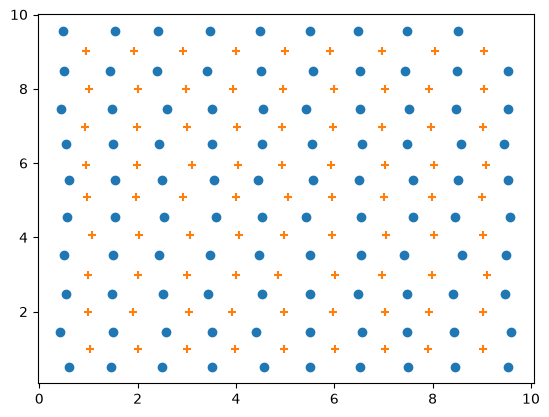

In [75]:
#plt.scatter(x=vr.vertices[:, 0], y=vr.vertices[:,1])
plt.scatter(x=coord[:99, 1], y=coord[:99, 2])
plt.scatter(x=coord[100:, 1], y=coord[100:, 2], marker="+")